
------ Cross-Validated Training Set Performance (5-fold) ------
              precision    recall  f1-score   support

        crop       0.65      0.42      0.52        40
        wild       0.57      0.78      0.66        40

    accuracy                           0.60        80
   macro avg       0.61      0.60      0.59        80
weighted avg       0.61      0.60      0.59        80


Cross-validation Accuracy (5-fold): 0.6000 ± 0.0935

------ Confusion Matrix ------


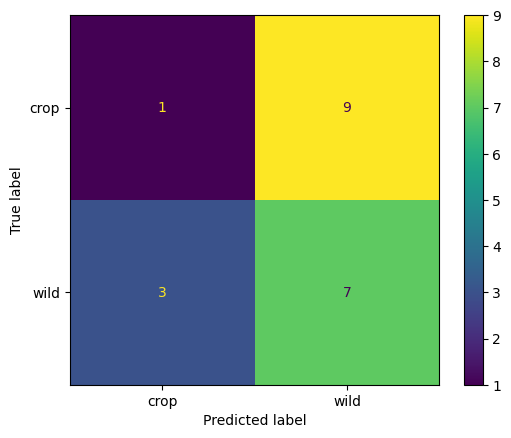


------ Misclassified Sequence IDs ------
NC_012799_CROP_(+1)
NC_055513_CROP_(+1)
NC_007729_CROP_(+1)
NC_027712_CROP_(+1)
NC_003056_CROP_(+1)
NC_009533_CROP_(+1)
NC_001367_CROP_(+1)
NC_003632_(+1)
NC_009532_CROP_(+1)
NC_002600_CROP_(+1)
NC_009041_WILD_(+1)
NC_055493_WILD_(+1)


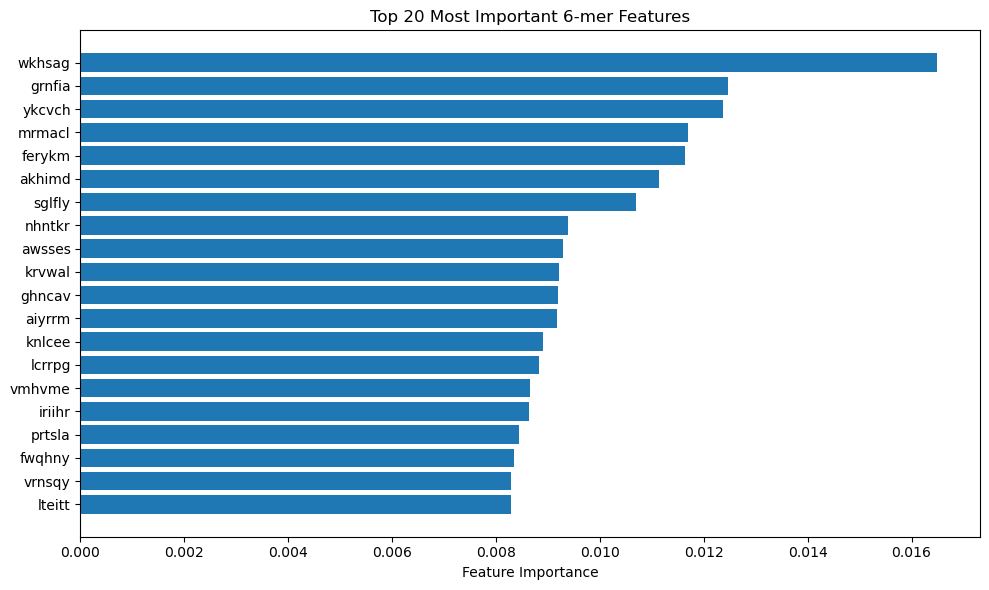

In [96]:
# Single fit testing

# Install required packages
# === Install Required Packages ===
!pip install biopython scikit-learn pandas matplotlib

# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

# === Load CSV ===
csv_path = "virus_metadata.csv"  # update this to your actual CSV path
df = pd.read_csv(csv_path)

# Filter and clean sequences
df['sequence'] = df['sequence'].str.upper().str.replace(r'[^ACGT]', '', regex=True)

# === Generate k-mers ===
def get_kmers(sequence, k=6):
    if len(sequence) < k:
        return ""
    return ' '.join([sequence[i:i+k] for i in range(len(sequence) - k + 1)])

k = 6
df['kmers'] = df['sequence'].apply(lambda x: get_kmers(x, k=k))

# Drop sequences shorter than k
df = df[df['kmers'].str.len() > 0].copy()

# === Encode labels ===
le = LabelEncoder()
df['label'] = le.fit_transform(df['type'])  # crop → 0, wild → 1

# === Split data ===
X_kmers = df['kmers']
y = df['label']
seq_ids = df['id']

X_train_kmers, X_test_kmers, y_train, y_test, ids_train, ids_test = train_test_split(
    X_kmers, y, seq_ids, test_size=0.2, stratify=y, random_state=42
)

# === Vectorize ===
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train_kmers)
X_test = vectorizer.transform(X_test_kmers)

# === Train Random Forest with Cross-Validation ===
rf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
y_train_pred = cross_val_predict(rf, X_train, y_train, cv=5)

# === Evaluate on Training Data ===
print("------ Cross-Validated Training Set Performance (5-fold) ------")
print(classification_report(y_train, y_train_pred, target_names=le.classes_))

cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f"Cross-validation Accuracy (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# === Final Model Fit and Test Prediction ===
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# === Confusion Matrix ===
print("\n------ Test Set Confusion Matrix ------")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.show()

# === Misclassified IDs ===
misclassified_ids = ids_test[y_pred != y_test]
print("\n------ Misclassified Sequence IDs ------")
for sid in misclassified_ids:
    print(sid)

# === Feature Importance Plot ===
importances = rf.feature_importances_
feature_names = np.array(vectorizer.get_feature_names_out())

# Filter to only k-mers of expected length (precautionary)
valid_indices = [i for i, feat in enumerate(feature_names) if len(feat) == k]
valid_importances = importances[valid_indices]
valid_feature_names = feature_names[valid_indices]

# Top 20 features
top_indices = np.argsort(valid_importances)[-20:]
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_indices)), valid_importances[top_indices], align='center')
plt.yticks(range(len(top_indices)), [valid_feature_names[i] for i in top_indices])
plt.xlabel('Feature Importance')
plt.title(f'Top 20 Most Important {k}-mer Features')
plt.tight_layout()
plt.show()


In [ ]:
# Hyperparameter tuning

# === Setup ===
# === Install Required Packages ===
!pip install scikit-learn pandas matplotlib

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# === Parameters ===
CSV_FILE = "virus_data.csv"  # your CSV should contain: id, type, family, length, sequence
KMER_SIZE = 4
RANDOM_STATE = 42
N_SPLITS = 5

# === K-mer Extraction ===
def get_kmers(sequence, k):
    sequence = sequence.upper()
    return ' '.join([sequence[i:i+k] for i in range(len(sequence) - k + 1)]) if len(sequence) >= k else ''

# === Load CSV Data ===
def load_data(csv_path, k):
    df = pd.read_csv(csv_path)
    df['sequence'] = df['sequence'].str.upper().str.replace(r'[^ACGT]', '', regex=True)
    df['kmers'] = df['sequence'].apply(lambda seq: get_kmers(seq, k))
    df = df[df['kmers'].str.len() > 0].copy()

    return df['kmers'], df['type'], df['id']

# === Random Forest Pipeline with Extended Grid Search ===
def run_random_forest_pipeline(kmers_train, y_train):
    pipeline = Pipeline([
        ("vectorizer", CountVectorizer()),
        ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
        ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
    ])

    # Expanded parameter grid for HPCC use
    param_grid = {
        "classifier__n_estimators": [100, 200, 500, 1000],
        "classifier__max_depth": [10, 20, 40, 80, None],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__max_features": ['sqrt', 'log2', None],
        "classifier__bootstrap": [True, False]
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=2
    )
    grid.fit(kmers_train, y_train)

    print("\n=== Best Random Forest Model ===")
    print("Best F1 Score:", grid.best_score_)
    print("Best Parameters:", grid.best_params_)

    return grid.best_estimator_

# === Evaluation ===
def evaluate_model(model, kmers_test, y_test, le):
    y_pred = model.predict(kmers_test)
    print("\n=== Evaluation on Test Dataset ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

# === Main ===
def main():
    kmers, labels, seq_ids = load_data(CSV_FILE, k=KMER_SIZE)

    le = LabelEncoder()
    y = le.fit_transform(labels)

    kmers_train, kmers_test, y_train, y_test = train_test_split(
        kmers, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    best_model = run_random_forest_pipeline(kmers_train, y_train)
    evaluate_model(best_model, kmers_test, y_test, le)

main()